# Deuteron electrodisintegration

_Last update:_ March 6, 2025

In [1]:
# Python imports
from functools import partial
from matplotlib.offsetbox import AnchoredText
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

In [2]:
# JAX imports
from jax import config, jit, vmap
import jax.numpy as jnp
from jax.numpy.linalg import eigh, solve
from jax.scipy.special import sph_harm, factorial
from jaxinterp2d import interp2d

In [3]:
# Imports from scripts
from scripts.clebsch_gordan import ClebschGordan
from scripts.figures import set_rc_parameters, label_channel
from scripts.integration import gaussian_quadrature_mesh
from scripts.tools import channel_L_value, coupled_channel, replace_periods

### Set-up

In [4]:
# Enable double precision
config.update("jax_enable_x64", True)

In [5]:
# Run this cell to turn on customized matplotlib graphics
set_rc_parameters()

## Classes

In [6]:
class SpecialFunctions:
    """Class for computing the first few associated Legendre polynomials and
    spherical harmonics.
    """

    @partial(jit, static_argnums=(0,))
    def ylm(self, theta, phi, L, M_L):
        """Spherical harmonic Y_{L M_L}(\theta, \phi) assuming the quantum
        mechanics sign convention. Note, if |M_L| > L this method returns 0.
        """
        
        sign = (-1) ** M_L
        plm = self.plm(jnp.cos(theta), L, M_L)
        exp = jnp.exp(1j * M_L * phi)
        
        return sign * plm * exp

    @partial(jit, static_argnums=(0,))
    def plm(self, x, L, M_L):
        """Associated Legendre polynomial P_{L M_L}(x). Note, if |M_L| > L
        this method returns 0.
        """
        
        cond = jnp.abs(M_L) <= L
        
        return jnp.where(cond, self.plm_all_m(x, L, M_L), 0)
    
    @partial(jit, static_argnums=(0,))
    def plm_all_m(self, x, L, M_L):
        """Associated Legendre polynomial P_{L M_L}(x) for all M_L."""
        
        cond = M_L < 0
        
        # Include normalization factor in Legendre polynomial
        factor = jnp.sqrt(
            (2 * L + 1) / (4 * jnp.pi) * factorial(L - M_L) / factorial(L + M_L)
        )
        
        return factor * jnp.where(cond, self.plm_negative_m(x, L, M_L),
                                  self.plm_positive_m(x, L, M_L))
        
    @partial(jit, static_argnums=(0,))
    def plm_negative_m(self, x, L, M_L):
        """Convert P_{L M_L}(x) to case where m is negative."""
        
        M_L_positive = -M_L
        sign = (-1) ** (M_L_positive)
        factor = factorial(L - M_L_positive) / factorial(L + M_L_positive)
        plm = self.plm_positive_m(x, L, M_L_positive)
        
        return sign * factor * plm
        
    @partial(jit, static_argnums=(0,))
    def plm_positive_m(self, x, L, M_L):
        """P_{L M_L}(x) for positive m."""
        
        condlist = [
            jnp.logical_and(L == 0, M_L == 0),
            jnp.logical_and(L == 1, M_L == 0),
            jnp.logical_and(L == 1, M_L == 1),
            jnp.logical_and(L == 2, M_L == 0),
            jnp.logical_and(L == 2, M_L == 1),
            jnp.logical_and(L == 2, M_L == 2),
        ]
        choicelist = [
            self.p00(x), self.p10(x), self.p11(x), self.p20(x), self.p21(x),
            self.p22(x)
        ]
        
        return jnp.select(condlist, choicelist)

    @partial(jit, static_argnums=(0,))
    def p00(self, x):
        """Associated Legendre polynomial with L = 0 and M_L = 0."""
        
        return jnp.ones_like(x)
    
    @partial(jit, static_argnums=(0,))
    def p10(self, x):
        """Associated Legendre polynomial with L = 1 and M_L = 0."""
        
        return x
    
    @partial(jit, static_argnums=(0,))
    def p11(self, x):
        """Associated Legendre polynomial with L = 1 and M_L = 1."""
        
        return -jnp.sqrt(1 - x ** 2)
    
    @partial(jit, static_argnums=(0,))
    def p20(self, x):
        """Associated Legendre polynomial with L = 2 and M_L = 0."""
        
        return (3 * x ** 2 - 1) / 2
    
    @partial(jit, static_argnums=(0,))
    def p21(self, x):
        """Associated Legendre polynomial with L = 2 and M_L = 1."""
        
        return -3 * x * jnp.sqrt(1 - x ** 2)
    
    @partial(jit, static_argnums=(0,))
    def p22(self, x):
        """Associated Legendre polynomial with L = 2 and M_L = 2."""
        
        return 3 * (1 - x ** 2)

In [7]:
class Potential:
    """Class that loads NN potentials as JAX arrays."""
    
    # Define class attribute for h-bar^2 / M [MeV fm^2]
    hbar_sq_over_m = 41.47
    
    def __init__(self, kvnn, kmax, kmid, ntot, L_max=2):
        
        # Need kvnn as string (can cause error if kvnn < 10)
        if kvnn < 10:
            kvnn_str = '0' + str(kvnn)
        else:
            kvnn_str = str(kvnn)
        self.kvnn_str = kvnn_str
        
        # Get potential directory
        kmax_int = int(kmax)
        kmid_int = int(kmid)
        self.directory = (
            f'../data/potentials/vsrg_kvnn_{kvnn_str}_lam12.0_kmax{kmax_int:d}'
            f'_kmid{kmid_int:d}_ntot{ntot:d}/'
        )

        # Set momentum mesh in units fm^-1
        self.k_array, self.k_weights = self.get_momentum_mesh()
        
        # Set momentum mesh specifications as attributes
        self.kmax, self.kmid, self.ntot = kmax, kmid, ntot
        
        # Set potentials up to L_max in a big JAX arrays distinguishing
        # uncoupled- or coupled-channel
        self.uncoupled_potentials, self.coupled_potentials = (
            self.get_potentials(L_max)
        )
        
    def get_momentum_mesh(self):
        """Momentum mesh in units [fm^-1] as JAX arrays."""
        
        filename = f'vsrg_1S0_kvnn_{self.kvnn_str}_lam12.0_reg_0_3_0_mesh.out'
        momentum_mesh = np.loadtxt(self.directory + filename)
        k_array = jnp.asarray(momentum_mesh[:, 0])
        k_weights = jnp.asarray(momentum_mesh[:, 1])
        
        return k_array, k_weights
    
    def get_potentials(self, L_max):
        """JAX arrays of potentials up to L_max returning uncoupled- and
        coupled-channel separately."""
        
        # Initialize potentials as lists later to be converted to JAX arrays
        uncoupled_potentials_list = []
        coupled_potentials_list = []
        
        # Possible partial wave channels up to L = 5
        channels = [
            '1S0', '3S1', '3P0', '1P1', '3P1', '3P2', '1D2', '3D2', '3D3',
            '1F3', '3F3', '3F4', '1G4', '3G4', '3G5', '1H5', '3H5', '3H6'
        ]
        
        # Loop over channels
        for channel in channels:

            # Check that channel is within L_max
            L = channel_L_value(channel)
            if L <= L_max:
                
                # Load potential [fm]
                V_matrix = self.load_potential(channel)

                # Coupled-channel
                if coupled_channel(channel):
                    coupled_potentials_list.append(V_matrix)
                # Uncoupled-channel
                else:
                    uncoupled_potentials_list.append(V_matrix)
                    
        # Convert lists to JAX arrays with shape (# of channels, ntot, ntot)
        uncoupled_potentials = jnp.asarray(uncoupled_potentials_list)
        coupled_potentials = jnp.asarray(coupled_potentials_list)

        return uncoupled_potentials, coupled_potentials

    def load_potential(self, channel):
        """Load the potential in the given partial wave channel."""
        
        filename = f'vnn_{channel}_kvnn_{self.kvnn_str}_lam12.0_reg_0_3_0.out'
        data = np.loadtxt(self.directory + filename)
        
        # Coupled-channel potential?
        if coupled_channel(channel):
        
            V11 = jnp.reshape(data[:, 2], (self.ntot, self.ntot))
            V12 = jnp.reshape(data[:, 3], (self.ntot, self.ntot))
            V21 = jnp.reshape(data[:, 4], (self.ntot, self.ntot))
            V22 = jnp.reshape(data[:, 5], (self.ntot, self.ntot))
            V_matrix = jnp.vstack(
                (jnp.hstack((V11, V12)), jnp.hstack((V21, V22)))
            )
        
        else:
        
            V_matrix = jnp.reshape(data[:, 2], (self.ntot, self.ntot))

        # Potential in units [fm] where the shape can vary
        return V_matrix
    
    def load_kinetic_energy(self, channel):
        """Loads relative kinetic energy."""

        # Matrix of (h-bar*k)^2 / M along diagonal [MeV]
        T_matrix = jnp.diag(self.k_array ** 2) * self.hbar_sq_over_m
    
        # Coupled-channel operator?
        if coupled_channel(channel):
        
            # Matrix of zeros (n x n)
            zeros = jnp.zeros((self.ntot, self.ntot))
        
            # Build coupled-channel kinetic energy matrix
            T_matrix = jnp.vstack(
                (jnp.hstack((T_matrix, zeros)), jnp.hstack((zeros, T_matrix)))
            )
        
        # Kinetic energy in units [MeV]
        return T_matrix
    
    def load_hamiltonian(self, channel):
        """Loads the Hamiltonian."""
        
        # Load relative kinetic energy [MeV]
        T_matrix = self.load_kinetic_energy(channel)
    
        # Load potential [fm]
        V_matrix_fm = self.load_potential(channel)

        # Convert potential from [fm] -> [MeV]
        V_matrix_MeV = self.hbar_sq_over_m * self.attach_integration_weights(
            V_matrix_fm, channel
        )
    
        H_matrix = T_matrix + V_matrix_MeV
    
        # Hamiltonian in units MeV
        return H_matrix
    
    def attach_integration_weights(self, V_matrix_fm, channel):
        """Attach integration k_i^2 w_i factor to potential."""
        
        # Get integration factor as a 1-D array
        factor_array = self.integration_measure(channel)
        
        # 1-D array to 2-D grid
        factor_i_grid, factor_j_grid = jnp.meshgrid(factor_array, factor_array,
                                                    indexing='ij')
    
        # Multiply the potential by the integration measure [fm^-2]
        return factor_i_grid * factor_j_grid * V_matrix_fm
    
    def integration_measure(self, channel):
        """Get factor k_i^2 w_i."""
        
        # Make array of integration factor [fm^-3/2]
        if coupled_channel(channel):
            factor_array = jnp.concatenate((
                jnp.sqrt(2 / jnp.pi * self.k_weights) * self.k_array,
                jnp.sqrt(2 / jnp.pi * self.k_weights) * self.k_array
            ))
        else:
            factor_array = jnp.sqrt(2 / jnp.pi * self.k_weights) * self.k_array
        
        # Return 1-D array with units [fm^-3/2]
        return factor_array

    @partial(jit, static_argnums=(0,))
    def get_uncoupled_potential(self, L, S, J):
        
        # Map L, S, and J onto index (special case for 3P0)
        cond = jnp.logical_and(L == 1, jnp.logical_and(S == 1, J == 0))
        index = jnp.where(cond, 1, L + S + J)
        
        # Units are [fm] and shape is (ntot, ntot)
        return self.uncoupled_potentials[index]
    
    @partial(jit, static_argnums=(0,))
    def get_coupled_potential(self, J):
        
        # Map J onto index
        index = J - 1
        
        # Units are [fm] and shape is (2*ntot, 2*ntot)
        return self.coupled_potentials[index]
    
    @partial(jit, static_argnums=(0,))
    def is_coupled(self, L, J):
        """Boolean value on whether the channel is coupled or not."""
        
        return jnp.logical_and(J > 0, J != L)

In [8]:
class DeuteronWaveFunction(Potential):
    """Class that computes the deuteron wave function."""
    
    def __init__(self, kvnn, kmax, kmid, ntot):
        
        # Initializes potentials up to
        super().__init__(kvnn, kmax, kmid, ntot)
        
        # Set deuteron wave function as instance attributes
        self.psi_0_array, self.psi_2_array = self.set_deuteron_wf()
        
    def set_deuteron_wf(self):
        """Get deuteron S- and D-wave functions."""

        # Hamiltonian in 3S1-3D1 coupled-channel [MeV]
        H_matrix = self.load_hamiltonian('3S1')

        # Diagonalize Hamiltonian for deuteron wave function [unitless]
        eigenvalues, eigenvectors = eigh(H_matrix)
        psi_d_unitless = eigenvectors[:, 0]  # Shape is (2*ntot, 1)
        
        # Remove factor k_i^2 w_i from deuteron wave function [fm^3/2]
        factor_array = self.integration_measure('3S1')
        psi_d_units = psi_d_unitless / factor_array

        # Split into S- and D-waves
        psi_0_array = psi_d_units[:self.ntot]  # S-wave [fm^3/2]
        psi_2_array = psi_d_units[self.ntot:]  # D-wave [fm^3/2]
        
        # Units are [fm^3/2] and shapes are (ntot, 1)
        return psi_0_array, psi_2_array
    
    @partial(jit, static_argnums=(0,))
    def compute_wf(self, k, L):
        """Compute the wave function at relative momenta k given orbital
        angular momentum L.
        """
        
        # List of conditions for S- or D-wave
        condlist = [L == 0, L == 2]
        
        # List of deuteron wave function in S- and D-wave
        choicelist = [
            jnp.interp(k, self.k_array, self.psi_0_array),
            jnp.interp(k, self.k_array, self.psi_2_array)
        ]
        
        # Deuteron wave function in units [fm^3/2] with shape (ntot, 1)
        return jnp.select(condlist, choicelist)

In [9]:
class FormFactors:
    """Form factors from Sushant's data files."""

    def __init__(self):
        """Interpolate data files."""
        
        gep_data = np.loadtxt("gep.dat")
        gen_data = np.loadtxt("gen.dat")
        
        # Set data as instance attributes
        self.Q2_gep_GeV = jnp.asarray(gep_data[:, 0])
        self.gep_array = jnp.asarray(gep_data[:, 1])
        self.Q2_gen_GeV = jnp.asarray(gen_data[:, 0])
        self.gen_array = jnp.asarray(gen_data[:, 1])

    @partial(jit, static_argnums=(0,))
    def GEp(self, Q2):
        """Electric proton form factor w.r.t. Q^2 in GeV^2."""

        return jnp.interp(Q2, self.Q2_gep_GeV, self.gep_array) * self.GD(Q2)
    
    @partial(jit, static_argnums=(0,))
    def GEn(self, Q2):
        """Electric neutron form factor w.r.t. Q^2 in GeV^2."""
        
        return jnp.interp(Q2, self.Q2_gen_GeV, self.gen_array)
    
    @partial(jit, static_argnums=(0,))
    def GD(self, Q2):
        """Dipole form factor w.r.t. Q^2 in GeV^2."""
        
        mD2 = 0.71  # GeV^2
        
        return (1 + Q2 / mD2) ** -2

In [10]:
class TMatrix(Potential):
    """Class that computes the NN T-matrix."""
    
    def __init__(self, kvnn, kmax, kmid, ntot, L_max=2):
        
        # Initializes potentials up to L_max
        super().__init__(kvnn, kmax, kmid, ntot, L_max)

        # Maximum momentum [fm^-1]
        self.lamb = kmax
        
    @partial(jit, static_argnums=(0,))
    def half_offshell(self, pp, L, Lp, S, J, T):
        """Compute the half off-shell T-matrix T_{L, L'}(k_i, p'; E'=p'^2/M)
        for a particular partial wave channel.
        """
        
        # T-matrix in units [fm] with shape (ntot+1, ntot+1)
        T_matrix = self.compute(pp, L, Lp, S, J, T)
        
        # Half off-shell T-matrix in units [fm] with shape (ntot, 1)
        return T_matrix[:self.ntot, self.ntot]
    
    @partial(jit, static_argnums=(0,))
    def onshell(self, pp, L, Lp, S, J, T):
        """Compute the on-shell T-matrix T_{L, L'}(p', p'; E'=p'^2/M) for a
        particular partial wave channel.
        """
        
        # T-matrix in units [fm] with shape (ntot+1, ntot+1)
        T_matrix = self.compute(pp, L, Lp, S, J, T)
        
        # Half off-shell T-matrix in units [fm] which is a complex scalar
        return T_matrix[self.ntot, self.ntot]
    
    @partial(jit, static_argnums=(0,))
    def compute(self, pp, L, Lp, S, J, T):
        """Compute the T-matrix for given momentum p' with energy E' = p'^2 / M
        for a particular partial wave channel. Note, this method returns a
        matrix of zeros if the partial wave channel is unphysical.
        """
        
        cond = self.channel_is_physical(L, Lp, S, J, T)
        
        # T-matrix in units [fm] with shape (ntot+1, ntot+1)
        return jnp.where(
            cond,
            self.compute_coupled_or_uncoupled(pp, L, Lp, S, J),
            jnp.zeros((self.ntot + 1, self.ntot + 1))
        )
    
    @partial(jit, static_argnums=(0,))
    def compute_coupled_or_uncoupled(self, pp, L, Lp, S, J):
        """Compute the T-matrix for given momentum p' with energy E' = p'^2 / M
        for any partial wave channel.
        """
        
        # Condition on whether the channel is coupled or not
        cond = self.is_coupled(L, J)
        T_matrix = jnp.where(
            cond, self.compute_coupled(pp, L, Lp, J),
            self.compute_uncoupled(pp, L, S, J)
        )
        
        # T-matrix in units [fm] with shape (ntot+1, ntot+1)
        return T_matrix
    
    @partial(jit, static_argnums=(0,))
    def compute_uncoupled(self, pp, L, S, J):
        """Compute the half off-shell T-matrix in a uncoupled-channel."""

        # Evaluate D-vector for solving matrix inversion problem
        D_vector = self.D_vector(pp)
        
        # Append p' to end of mesh (ntot+1,)
        k_full = jnp.append(self.k_array, pp)
        
        # Create meshes for interpolation (ntot+1, ntot+1)
        k_grid, kp_grid = jnp.meshgrid(k_full, k_full, indexing='ij')
        
        # Load potential in units [fm] with shape (ntot, ntot)
        V_matrix = self.get_uncoupled_potential(L, S, J)

        # Append p' points by linear interpolation (ntot+1, ntot+1)
        V_interpolated = interp2d(k_grid, kp_grid, self.k_array, self.k_array,
                                  V_matrix)
        
        # Build F-matrix [unitless] where F_ij = \delta_ij + D_j V_ij
        F_matrix = (jnp.identity(self.ntot + 1)
                    + jnp.tile(D_vector, (self.ntot + 1, 1)) * V_interpolated)

        # Solve for T-matrix by matrix inversion
        T_matrix = solve(F_matrix, V_interpolated)

        # Units are [fm] and shape is (ntot+1, ntot+1)
        return T_matrix
    
    @partial(jit, static_argnums=(0,))
    def compute_coupled(self, pp, L, Lp, J):
        """Compute the half off-shell T-matrix in a coupled-channel."""
        
        # Evaluate D-vector for solving matrix inversion problem
        D_vector = self.D_vector(pp)
        
        # Append p' to end of mesh (ntot+1,)
        k_full = jnp.append(self.k_array, pp)
        
        # Create meshes for interpolation (ntot+1, ntot+1)
        k_grid, kp_grid = jnp.meshgrid(k_full, k_full, indexing='ij')
        
        # Load potential in units [fm] with shape (2*ntot, 2*ntot)
        V_matrix = self.get_coupled_potential(J)

        # Append p' points by linear interpolation (2*ntot+2, 2*ntot+2)
        V_interpolated = self.interpolate_coupled_potential(k_grid, kp_grid,
                                                            V_matrix)
        
        # Build F-matrix [unitless] where F_ij = \delta_ij + D_j V_ij
        F_matrix = (
            jnp.identity(2 * (self.ntot + 1))
            + jnp.tile(D_vector, (2 * (self.ntot + 1), 2)) * V_interpolated
        )

        # Solve for T-matrix by matrix inversion
        T_matrix = solve(F_matrix, V_interpolated)
        
        # Select particular sub-block of coupled-channel matrix
        T_subblock = self.select_subblock(L, Lp, J, T_matrix)

        # Units are [fm] and shape is (ntot+1, ntot+1)
        return T_subblock
    
    @partial(jit, static_argnums=(0,))
    def D_vector(self, pp):
        """Compute D-vector used for solving matrix inversion problem:
            T = F^-1 V
        where F_ij = \delta_ij + D_j V_ij.
        """
        
        # First ntot elements of D_vector [fm^-1]
        D_vector = (2.0 / jnp.pi * (self.k_weights * self.k_array ** 2)
                    / (self.k_array ** 2 - pp ** 2))
        
        # ntot + 1 element of D_vector [fm^-1]
        D_last = (
            -2.0 / jnp.pi * pp ** 2 * (
                jnp.sum(self.k_weights / (self.k_array ** 2 - pp ** 2))
                + jnp.log((self.lamb + pp) / (self.lamb - pp)) / (2.0 * pp)
            )
        ) + 1j * pp
        
        # Append ntot + 1 element to D_vector
        return jnp.append(D_vector, D_last)

    @partial(jit, static_argnums=(0,))
    def interpolate_coupled_potential(self, k_grid, kp_grid, V_matrix):
        """Interpolate half off-shell T-matrix matrix in a coupled-channel."""
        
        # Get each sub-block separately with shapes (ntot, ntot)
        V11, V12, V21, V22 = self.get_subblocks(V_matrix)
        
        # Append p' points by linear interpolation (ntot+1, ntot+1)
        V11_interpolated = interp2d(k_grid, kp_grid, self.k_array, self.k_array,
                                    V11)
        V12_interpolated = interp2d(k_grid, kp_grid, self.k_array, self.k_array,
                                    V12)
        V21_interpolated = interp2d(k_grid, kp_grid, self.k_array, self.k_array,
                                    V21)
        V22_interpolated = interp2d(k_grid, kp_grid, self.k_array, self.k_array,
                                    V22)
        
        # Recombine sub-blocks for coupled-channel matrix
        V_interpolated = jnp.vstack((
            jnp.hstack((V11_interpolated, V12_interpolated)),
            jnp.hstack((V21_interpolated, V22_interpolated))
        ))

        # Shape is (2*ntot+2, 2*ntot+2)
        return V_interpolated
    
    @partial(jit, static_argnums=(0,))
    def select_subblock(self, L, Lp, J, T_matrix):
        """Select a particular sub-block (L and L') of a coupled-channel T-
        matrix.
        """
        
        # List of conditions for each sub-block
        condlist = [
            jnp.logical_and(L == Lp, J > L),   # 0-0 sub-block
            jnp.logical_and(L != Lp, J > L),   # 0-2 sub-block
            jnp.logical_and(L != Lp, J > Lp),  # 2-0 sub-block
            jnp.logical_and(L == Lp, J < L)    # 2-2 sub-block
        ]
        
        # List of the T-matrix in each sub-block
        choicelist = [
            T_matrix[:self.ntot+1, :self.ntot+1],
            T_matrix[:self.ntot+1, self.ntot+1:],
            T_matrix[self.ntot+1:, :self.ntot+1],
            T_matrix[self.ntot+1:, self.ntot+1:]
        ]
        
        # Get particular sub-block with shape (ntot+1, ntot+1)
        T_subblock = jnp.select(condlist, choicelist)
        
        # Units remain [fm]
        return T_subblock
    
    @partial(jit, static_argnums=(0,))
    def get_subblocks(self, V_matrix):
        """Gets each sub-block (L and L') from a coupled-channel potential."""
        
        V11 = V_matrix[:self.ntot, :self.ntot]
        V12 = V_matrix[:self.ntot, self.ntot:]
        V21 = V_matrix[self.ntot:, :self.ntot]
        V22 = V_matrix[self.ntot:, self.ntot:]

        return V11, V12, V21, V22
    
    @partial(jit, static_argnums=(0,))
    def channel_is_physical(self, L, Lp, S, J, T):
        """Check if the partial wave channel is physical."""

        # Make sure |L - S| <= J <= L + S and likewise with L'
        J_bool = jnp.logical_and(
            jnp.logical_and(
                jnp.less_equal(jnp.abs(L - S), J),
                jnp.less_equal(J, L + S)
            ),
            jnp.logical_and(
                jnp.less_equal(jnp.abs(Lp - S), J),
                jnp.less_equal(J, Lp + S)
            )
        )
        
        # Make sure L + S + T and L' + S + T are odd
        T_bool = jnp.logical_and(
            jnp.not_equal((L + S + T) % 2, 0),
            jnp.not_equal((Lp + S + T) % 2, 0)
        )
    
        return jnp.logical_and(J_bool, T_bool)

In [11]:
class FinalState:
    """
    Final-state wave function without plane-wave term evaluated at k_i != p'.
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot):
        
        # Set table of Clebsch-Gordan coefficients with j_max = 2
        self.cg = ClebschGordan(2)
        
        # Initialize T-matrix class
        self.tmatrix = TMatrix(kvnn, kmax, kmid, ntot)

    @partial(jit, static_argnums=(0,))
    def delta_psi(self, pp):

        # Not sure about these!
        m_J_d = 0
        m_S_f = 0
        
        k_array = self.tmatrix.k_array
        delta_psi = jnp.zeros(self.tmatrix.ntot, dtype=complex)
        
        # Denominator of Green's function without imaginary part
        greens_func = 1 / (pp ** 2 - k_array ** 2)
        
        # Sum over L' = 0, 2 with L, S, and J fixed
        L, S, J, T = 0, 1, 1, 0

        # Half off-shell T-matrix in units [fm]
        T_0_array = self.tmatrix.half_offshell(pp, L, 0, S, J, T)  # L' = 0
        T_2_array = self.tmatrix.half_offshell(pp, L, 2, S, J, T)  # L' = 2
            
        # Look-up Clebsch-Gordan coefficients
        cg_0 = self.cg.get_coefficient(0, m_J_d - m_S_f, S, m_S_f, J, m_J_d)
        cg_2 = self.cg.get_coefficient(2, m_J_d - m_S_f, S, m_S_f, J, m_J_d)
            
        # Extra factor of 2 from [1 + (-1)^T (-1) L']
        delta_psi = 0.5 * jnp.sqrt(2/np.pi) * greens_func * 2 * (
            T_0_array * cg_0 + T_2_array * cg_2
        )
            
        return k_array, delta_psi

In [12]:
class DeuteronElectrodisintegration:
    """Class that calculates the longitudinal structure function for deuteron
    electrodisintegration.
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, fsi=False, L_max=2):

        # Constants will be used as instance attributes
        self.hbar_c = 197.32696  # \hbar c [MeV fm]
        M_n = 939.56563  # Neutron mass [MeV]
        M_p = 938.27231  # Proton mass [MeV]
        self.M = (M_p + M_n) / 2  # Nucleon mass [MeV]
        B_d = 2.224  # Binding energy of deuteron [MeV]
        self.M_d = 2 * self.M - B_d  # Deuteron mass [MeV]
        self.alpha = 1 / 137.03599  # Fine structure constant
        
        # Quantum numbers for longitudinal structure function S_f, m_S_f, m_J_d
        self.fL_quantum_numbers = self.fL_sum()
        
        # Load form factors from data files
        self.ff = FormFactors()
        
        # Include FSI?
        if fsi:
            overlap_ia = ImpulseApproximation(kvnn, kmax, kmid, ntot, L_max)
            overlap_fsi = FinalStateInteraction(kvnn, kmax, kmid, ntot, L_max)
            self.overlap = (
                lambda pp, thetap, q, gep, gen, fL_quantum_numbers:
                    overlap_ia(pp, thetap, q, gep, gen, fL_quantum_numbers)
                    + overlap_fsi(pp, thetap, q, gep, gen, fL_quantum_numbers)
            )
        else:
            self.overlap = ImpulseApproximation(kvnn, kmax, kmid, ntot, L_max)

    def fL_sum(self):
        """Repackage sum over S_f, m_S_f, and m_J_d into a JAX array."""
        
        fL_list = []
        
        # Possible values of S_f and m_J_d
        S_f_array = jnp.array([0, 1])
        m_J_d_array = jnp.array([-1, 0, 1])
        
        # Sum over S_f, m_S_f, and m_J_d
        for S_f in S_f_array:
            
            m_S_f_array = jnp.arange(-S_f, S_f + 1, 1)
            for m_S_f in m_S_f_array:
                
                for m_J_d in m_J_d_array:
                    
                    # Nothing depends on S_f!
                    fL_list.append([m_S_f, m_J_d])

        # Return as JAX array
        return jnp.asarray(fL_list)
    
    @partial(jit, static_argnums=(0,))
    def fL_vmap_theta(self, Ep, thetap_array, q):
        """Longitudinal structure function f_L [fm] with respect to scalars E'
        [MeV] and q [fm^-1] and array \theta' [deg].
        """

        # Vectorize fL method over theta'
        return vmap(self.fL, in_axes=(None, 0, None))(Ep, thetap_array, q)
    
    @partial(jit, static_argnums=(0,))
    def fL_quasifree_ridge(self, Ep_array, thetap):
        """Longitudinal structure function f_L [fm] with respect to scalar
        \theta' [deg] and array E' [MeV] where \omega = 0.
        """
        
        # Quasifree ridge where \omega = 0 determines q [fm^-1]
        q_array = jnp.sqrt(
            (Ep_array + 2 * self.M) ** 2 - self.M_d ** 2
        ) / self.hbar_c
        
        # Vectorize fL method over E' and q
        return vmap(self.fL, in_axes=(0, None, 0))(Ep_array, thetap, q_array)
    
    @partial(jit, static_argnums=(0,))
    def fL(self, Ep, thetap, q):
        """Longitudinal structure function f_L [fm] where the arguments are E'
        [MeV], \theta' [deg], and q [fm^-1].
        """
        
        # Convert \theta' to radians
        thetap_radians = jnp.radians(thetap)

        # Outgoing proton momentum [fm^-1]
        pp = jnp.sqrt(self.M * Ep + Ep ** 2 / 4) / self.hbar_c
        
        # Nucleon energy [MeV]
        E_N = jnp.sqrt((self.hbar_c * pp) ** 2 + self.M ** 2)
        
        # Virtual momentum q in units [MeV]
        q_MeV = self.hbar_c * q
        
        # Deuteron energy [MeV]
        E_d = jnp.sqrt(q_MeV ** 2 + self.M_d ** 2)
        
        # Energy of virtual photon [MeV]
        omega = Ep - E_d + 2 * self.M
        
        # Four momentum transfer squared [GeV^2]
        Q2 = (q_MeV ** 2 - omega ** 2) * 1e-6
        
        # Compute form factors [unitless]
        gep = self.ff.GEp(Q2)
        gen = self.ff.GEn(Q2)
        
#         ### TESTING
#         gep = 1.0
#         gen = 0.0
        
        # Kinematic factor [fm^-1]
        factor = -jnp.pi * jnp.sqrt(2 * self.alpha * pp * E_N * E_d / self.M_d
                                    / self.hbar_c)

        # Vectorize amplitude over all S_f, m_S_f, and m_J_d combinations
        amplitude_array = factor * vmap(
            self.overlap, in_axes=(None, None, None, None, None, 0)
        )(pp, thetap_radians, q, gep, gen, self.fL_quantum_numbers)
        
        # Sum amplitude absolute value squared over S_f, m_S_f, and m_J_d
        f_L = jnp.sum(jnp.abs(amplitude_array) ** 2)

        # Return longitudinal structure function [fm] which is a scalar
        return f_L

In [13]:
class Overlap:
    """Class for handling how to compute the overlap matrix element in the
    longitudinal structure function.
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, L_max):
        
        # Set table of Clebsch-Gordan coefficients with j_max = L_max + 1
        self.cg = ClebschGordan(L_max + 1)
        
        # Set-up spherical harmonics and Legendre polynomials
        self.sf = SpecialFunctions()
        
        # Set-up deuteron wave function as instance attribute
        self.dwf = DeuteronWaveFunction(kvnn, kmax, kmid, ntot)
        
        # Set L_max as instance attribute
        self.L_max = L_max
        
        # Array for sum over L_d
        self.L_d_array = jnp.array([0, 2])

In [14]:
class ImpulseApproximation(Overlap):
    """Class for calculating the overlap matrix element in the impulse
    approximation.
        < \phi | J_0 | \psi_i >
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, L_max):

        # Initializes overlaps
        super().__init__(kvnn, kmax, kmid, ntot, L_max)
    
    @partial(jit, static_argnums=(0,))
    def __call__(self, pp, thetap, q, gep, gen, fL_quantum_numbers):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        and m_J_d.
        """
        
        # Unpack f_L quantum numbers (no dependence on S_f)
        m_S_f, m_J_d = fL_quantum_numbers

        # Vectorize overlap method over L_d
        overlap_array = vmap(
            self.overlap_wrt_Ld,
            in_axes=(None, None, None, None, None, None, None, 0)
        )(pp, thetap, q, gep, gen, m_S_f, m_J_d, self.L_d_array)
        
        # Sum over L_d
        overlap = jnp.sum(overlap_array)
        
        # Return overlap [fm^3/2] which is a scalar
        return overlap

    @partial(jit, static_argnums=(0,))
    def overlap_wrt_Ld(self, pp, thetap, q, gep, gen, m_S_f, m_J_d, L_d):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        m_J_d, and L_d.
        """
        
        m_L_d = m_J_d - m_S_f

        # Dot product p'_vector \dot q_vector [fm^-2]
        pqx = pp * q * jnp.cos(thetap)
        
        # Magnitude of momenta |p'_vector +/- q_vector / 2| [fm^-1]
        pq_minus = jnp.sqrt(pp ** 2 + q ** 2 / 4 - pqx)
        pq_plus = jnp.sqrt(pp ** 2 + q ** 2 / 4 + pqx)
        
        # Angles between the unit vector z^\hat and p'_vector -/+ q_vector / 2
        theta_minus = jnp.arccos((pp * jnp.cos(thetap) - q / 2) / pq_minus)
        theta_plus = jnp.arccos((pp * jnp.cos(thetap) + q / 2) / pq_plus)
        
        # CG < L_d m_J_d - m_S_f S = 1 m_S_f | J = 1 m_J_d >
        cg = self.cg.get_coefficient(L_d, m_L_d, 1, m_S_f, 1, m_J_d)
                
        # Spherical harmonics
        theta_array = jnp.array([theta_minus, theta_plus])
        phip_array = jnp.zeros_like(theta_array)
        # Quantum numbers must have same shape as \theta and \phi
        L_d_array = jnp.repeat(L_d, 2)
        m_L_d_array = jnp.repeat(m_L_d, 2)
        Ylm_array = sph_harm(m_L_d_array, L_d_array, phip_array, theta_array,
                             n_max=self.L_max)
        Ylm_minus, Ylm_plus = Ylm_array
 
        # Deuteron wave function [fm^3/2]
        psi_minus = self.dwf.compute_wf(pq_minus, L_d)
        psi_plus = self.dwf.compute_wf(pq_plus, L_d)

        # Compute overlap [fm^3/2] which is a scalar
        overlap = jnp.sqrt(2 / jnp.pi) * cg * (
            gep * psi_minus * Ylm_minus + gen * psi_plus * Ylm_plus
        )
                
        return overlap

In [15]:
class FinalStateInteraction(Overlap):
    """Class for calculating final state interactions of the overlap matrix
    element.
        < \phi | T^\dagger G_0^\dagger J_0 | \psi_i >
    """
    
    def __init__(self, kvnn, kmax, kmid, ntot, L_max):
        
        # Initializes overlaps
        super().__init__(kvnn, kmax, kmid, ntot, L_max)
        
        # Initialize T-matrix class
        self.tmatrix = TMatrix(kvnn, kmax, kmid, ntot, L_max)
        
        # Arrays for sums over quantum numbers
        self.T_1_array = jnp.array([0, 1])
        self.L_array = jnp.arange(0, L_max + 1, 1)
        self.m_s_array = jnp.array([-1, 0, 1])
        self.J_1_array = jnp.arange(0, L_max + 2, 1)
        
        # Set cos(\theta) integration mesh
        self.ntot_theta = 15
        theta_array, theta_weights = gaussian_quadrature_mesh(np.pi,
                                                              self.ntot_theta)
        self.theta_array = jnp.asarray(theta_array)
        self.theta_weights = jnp.asarray(theta_weights)
        
        # Meshgrids for integrations over \theta and k_2
        self.theta_grid, self.k2_grid = jnp.meshgrid(
            self.theta_array, self.tmatrix.k_array, indexing='ij'
        )
        _, self.dk2_grid = jnp.meshgrid(self.theta_weights,
                                        self.tmatrix.k_weights, indexing='ij')
        
        # Jacobian for \theta
        self.theta_jacobian = self.theta_weights * jnp.sin(self.theta_array)

    @partial(jit, static_argnums=(0,))
    def __call__(self, pp, thetap, q, gep, gen, fL_quantum_numbers):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        and m_J_d.
        """
        
        # Unpack f_L quantum numbers (no dependence on S_f)
        m_S_f, m_J_d = fL_quantum_numbers

        # Vectorize overlap method over T_1
        overlap_array = vmap(
            self.overlap_wrt_T1,
            in_axes=(None, None, None, None, None, None, None, 0)
        )(pp, thetap, q, gep, gen, m_S_f, m_J_d, self.T_1_array)
        
        # Sum over T_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_T1(self, pp, thetap, q, gep, gen, m_S_f, m_J_d, T_1):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        m_J_d, and T_1.
        """
        
        # Form factor part
        form_factors = gep + (-1) ** T_1 * gen
        
        # Vectorize overlap method over L_1
        overlap_array = form_factors * vmap(
            self.overlap_wrt_L1,
            in_axes=(None, None, None, None, None, None, 0)
        )(pp, thetap, q, m_S_f, m_J_d, T_1, self.L_array)
        
        # Sum over L_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L1(self, pp, thetap, q, m_S_f, m_J_d, T_1, L_1):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        m_J_d, T_1, and L_1.
        """

        # T_1 and L_1 factor
        factor_T1_L1 = 1 + (-1) ** T_1 * (-1) ** L_1
        
        # Spherical harmonic w.r.t. \theta'
        Y_L_1 = self.sf.ylm(thetap, 0.0, L_1, m_J_d - m_S_f)
        
        # Vectorize overlap method over J_1
        overlap_array = factor_T1_L1 * Y_L_1 * vmap(
            self.overlap_wrt_J1,
            in_axes=(None, None, None, None, None, None, None, 0)
        )(pp, thetap, q, m_S_f, m_J_d, T_1, L_1, self.J_1_array)
        
        # Sum over J_1
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_J1(self, pp, thetap, q, m_S_f, m_J_d, T_1, L_1, J_1):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        m_J_d, T_1, L_1, and J_1.
        """
        
        # CG < L_1 m_J_d - m_S_f S = 1 m_S_f | J_1 m_J_d >
        cg_J1_L1 = self.cg.get_coefficient(L_1, m_J_d - m_S_f, 1, m_S_f, J_1,
                                           m_J_d)
        
        # Vectorize overlap method over L_2
        overlap_array = cg_J1_L1 * vmap(
            self.overlap_wrt_L2,
            in_axes=(None, None, None, None, None, None, None, None, 0)
        )(pp, thetap, q, m_S_f, m_J_d, T_1, L_1, J_1, self.L_array)
        
        # Sum over L_2
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_L2(self, pp, thetap, q, m_S_f, m_J_d, T_1, L_1, J_1, L_2):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        m_J_d, T_1, L_1, J_1, and L_2.
        """
        
        # Call T-matrix for given partial wave channel [fm]
        T_matrix = jnp.conj(self.tmatrix.compute(pp, L_2, L_1, 1, J_1, T_1))

        # Half off-shell T-matrix with shape is (ntot_k, 1)
        ntot_k = self.tmatrix.ntot
        T_half_offshell_array = T_matrix[:ntot_k, ntot_k]
        # Convert to grid (shape is (ntot_theta, ntot_k))
        T_half_offshell_grid = jnp.tile(T_half_offshell_array,
                                        (self.ntot_theta, 1))
        
        # On-shell T-matrix (scalar)
        T_onshell = T_matrix[ntot_k, ntot_k]
    
        # Vectorize overlap method over m_s
        overlap_array = vmap(
            self.overlap_wrt_ms,
            in_axes=(
                None, None, None, None, None, None, None, None, None, None,
                None, 0
            )
        )(
            pp, thetap, q, T_half_offshell_grid, T_onshell, m_S_f, m_J_d, T_1,
            L_1, J_1, L_2, self.m_s_array
        )
        
        # Sum over m_s
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_ms(
            self, pp, thetap, q, T_half_offshell_grid, T_onshell, m_S_f, m_J_d,
            T_1, L_1, J_1, L_2, m_s
    ):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        m_J_d, T_1, L_1, J_1, L_2, and m_s.
        """

        # CG < J_1 m_J_d | L_2 m_J_d - m_s S=1 m_s >
        m_L_2 = m_J_d - m_s
        cg_J1_L2 = self.cg.get_coefficient(L_2, m_L_2, 1, m_s, J_1, m_J_d)
        
        # Legendre polynomial for L_2
        P_L_2_array = self.sf.plm(jnp.cos(self.theta_array), L_2, m_L_2)
        
        # Vectorize overlap method over L_d
        overlap_array = cg_J1_L2 * vmap(
            self.overlap_wrt_Ld,
            in_axes=(
                None, None, None, None, None, None, None, None, None, None,
                None, None, None, 0
            )
        )(
            pp, thetap, q, T_half_offshell_grid, T_onshell, P_L_2_array,
            m_S_f, m_J_d, T_1, L_1, J_1, L_2, m_s, self.L_d_array
        )
        
        # Sum over L_d
        return jnp.sum(overlap_array)
    
    @partial(jit, static_argnums=(0,))
    def overlap_wrt_Ld(
            self, pp, thetap, q, T_half_offshell_grid, T_onshell, P_L_2_array,
            m_S_f, m_J_d, T_1, L_1, J_1, L_2, m_s, L_d
    ):
        """Overlap matrix element [fm^3/2] for particular values of S_f, m_S_f,
        m_J_d, T_1, L_1, J_1, L_2, m_s, and L_d.
        """

        # Dot product k2_vector \dot q_vector
        k2qx_grid = self.k2_grid * q * jnp.cos(self.theta_grid)
        # Magnitude of momenta |k2_vector - q_vector / 2|
        k2q_minus_grid = jnp.sqrt(self.k2_grid ** 2 + q ** 2 / 4 - k2qx_grid)
        # Angle between the unit vector z^\hat and k2_vector - q_vector / 2
        cos_alphap_k2 = ((self.k2_grid * jnp.cos(self.theta_grid) - q / 2)
                         / k2q_minus_grid)

        # Same stuff as above but for k_2 = p'
        ppqx_array = pp * q * jnp.cos(self.theta_array)
        ppq_minus_array = jnp.sqrt(pp ** 2 + q ** 2 / 4 - ppqx_array)
        cos_alphap_pp = ((pp * jnp.cos(self.theta_array) - q / 2)
                         / ppq_minus_array)
        
        # Denominator of Green's function
        greens_func_grid = 1 / (pp ** 2 - self.k2_grid ** 2)

        # CG < L_d m_J_d - m_s S=1 m_s | J=1 m_J_d >
        m_L_d = m_J_d - m_s
        cg_Jd_Ld = self.cg.get_coefficient(L_d, m_L_d, 1, m_s, 1, m_J_d)

        # Legendre polynomials for L_d
        P_L_d_pp_array = self.sf.plm(cos_alphap_pp, L_d, m_L_d)
        P_L_d_k2_grid = self.sf.plm(cos_alphap_k2, L_d, m_L_d)

        # Deuteron wave function [fm^3/2]
        psi_k2_grid = self.dwf.compute_wf(k2q_minus_grid, L_d)
        psi_pp_array = self.dwf.compute_wf(ppq_minus_array, L_d)
        
        # Define functions f(k_2, \theta) [fm^1/2] where k_2 != p' and k_2 = p'
        f_k2_grid = (self.k2_grid ** 2 * T_half_offshell_grid * P_L_d_k2_grid 
                     * psi_k2_grid)
        f_pp_array = pp ** 2 * T_onshell * P_L_d_pp_array * psi_pp_array
            
        # Integrate over k_2 for p' != k_2 term [fm^3/2]
        integral_1 = jnp.sum(self.dk2_grid * f_k2_grid * greens_func_grid,
                             axis=-1)
            
        # Integrate over k_2 for p' = k_2 term [fm]
        integral_2 = jnp.sum(self.dk2_grid * greens_func_grid, axis=-1)
            
        # Integrate over \theta [fm^3/2]
        lamb = self.tmatrix.lamb
        integrand_theta = P_L_2_array * (
            integral_1 - f_pp_array * (
                integral_2 - 1 / (2 * pp) * (
                    jnp.log((lamb + pp) / (lamb - pp)) + 1j * jnp.pi
                )
            )
        )
        integral_theta = jnp.sum(self.theta_jacobian * integrand_theta)

        # Compute overlap
        overlap = jnp.sqrt(2 / np.pi) * cg_Jd_Ld * integral_theta

        # Factor of 2 for < J_0 > = 2 < J_0^- > (Eq. 20 in More 2015)
        return 2 * overlap

## Functions

In [16]:
def plot_delta_psi(pp, x_limits=(0,7), y_limits=(1e-4,1e1)):
    """Plot the magnitude of the FSI term in the final state wave function."""
    
    kvnn, kmax, kmid, ntot = 6, 30.0, 4.0, 120
    fsi = FinalState(kvnn, kmax, kmid, ntot)
    k_array, delta_psi_array = fsi.delta_psi(pp)
    
    plt.close('all')
    f, ax = plt.subplots(figsize=(4, 3))
    ax.semilogy(k_array, np.abs(delta_psi_array))
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    ax.set_title(label_channel('3S1', False) + '\t\t'
                 + rf"$p'={pp:.2f}\,$fm$^{{-1}}$")
    ax.set_xlabel(r"$k$ [fm$^{-1}$]", fontsize=16)
    ax.set_ylabel(r"$|\Delta \psi(k)|$ [fm$^3$]", fontsize=16);

In [17]:
def plot_fL_wrt_thetap(Ep, thetap_array, q, x_limits=None, y_limits=None):
    """Plot the longitudinal structure function with respect to E'."""
    
    # AV18
    kvnn, kmax, kmid, ntot = 6, 30.0, 4.0, 120
    
    ### TESTING CD-BONN
    # kvnn, kmax, kmid, ntot = 7, 15.0, 3.0, 120
    
    # Longitudinal structure function
    de_ia = DeuteronElectrodisintegration(kvnn, kmax, kmid, ntot, fsi=False)
    f_L_ia_array = de_ia.fL_vmap_theta(Ep, thetap_array, q)
    de_fsi = DeuteronElectrodisintegration(kvnn, kmax, kmid, ntot, fsi=True)
    f_L_fsi_array = de_fsi.fL_vmap_theta(Ep, thetap_array, q)

    plt.close('all')
    f, ax = plt.subplots(figsize=(4, 3))
    ax.plot(thetap_array, f_L_ia_array, label='Impulse approximation')
    ax.plot(thetap_array, f_L_fsi_array, label='FSI', ls='dashdot')
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_title(rf"$E'={Ep:d}$ [MeV], $\mathbf{{q}}^2={q**2:.1f}$ [fm$^{{-2}}$]")
    ax.set_xlabel(r"$\theta'$ [deg]", fontsize=16)
    ax.set_ylabel(r"$f_L$ [fm]", fontsize=16);

In [18]:
def plot_fL_quasifree_ridge(
        Ep_array, thetap, x_limits=None, y_limits=None, calc=False
):
    """Plot the longitudinal structure function with respect to E' where
    \omega = 0.
    """
    
    # AV18
    kvnn, kmax, kmid, ntot = 6, 30.0, 4.0, 120
    
    # Longitudinal structure function
    filename = replace_periods(f"f_L_quasifree_ridge_thetap{thetap:.1f}")
    if calc:
        de_ia = DeuteronElectrodisintegration(kvnn, kmax, kmid, ntot, fsi=False)
        f_L_ia_array = de_ia.fL_quasifree_ridge(Ep_array, thetap)
        de_fsi = DeuteronElectrodisintegration(kvnn, kmax, kmid, ntot, fsi=True)
        f_L_fsi_array = de_fsi.fL_quasifree_ridge(Ep_array, thetap)
        data = np.vstack((Ep_array, f_L_ia_array, f_L_fsi_array)).T
        hdr = ("E' [MeV], f_L (IA) [fm], f_L (FSI) [fm]\n")
        np.savetxt(filename + '.txt', data, header=hdr)
    else:
        data = np.loadtxt(filename + '.txt')
        f_L_ia_array = data[:, 1]
        f_L_fsi_array = data[:, 2]
    
    plt.close('all')
    f, ax = plt.subplots(figsize=(4, 3))
    ax.plot(Ep_array, f_L_ia_array, label='Impulse approximation')
    ax.plot(Ep_array, f_L_fsi_array, label='FSI', ls='dashdot')
    ax.set_xlim(x_limits)
    ax.set_ylim(y_limits)
    ax.legend(fontsize=9, loc='upper right')
    ax.set_title(rf"$\theta' = {thetap:.1f}$ [deg]")
    ax.set_xlabel(r"$E'$ [MeV]", fontsize=16)
    ax.set_ylabel(r"$f_L$ [fm]", fontsize=16);

## Tests

### $\lvert \Delta \psi(k) \rvert$

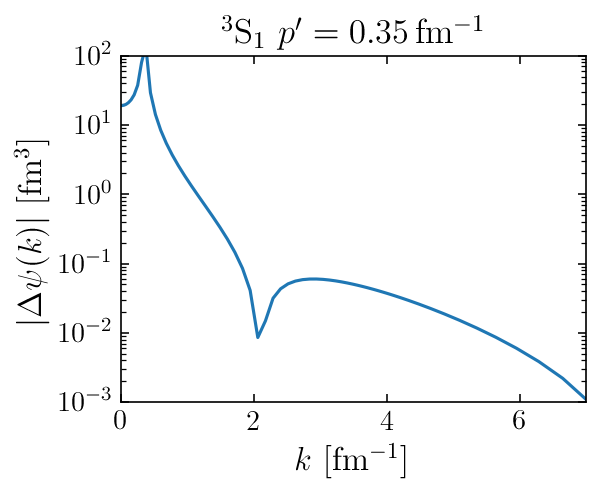

In [19]:
pp = 0.35
plot_delta_psi(pp, x_limits=(0,7), y_limits=(1e-3,1e2))

### Impulse approximation

In [20]:
thetap_array = jnp.linspace(0.01, 179.9, 100)
xlim = (0, 180)

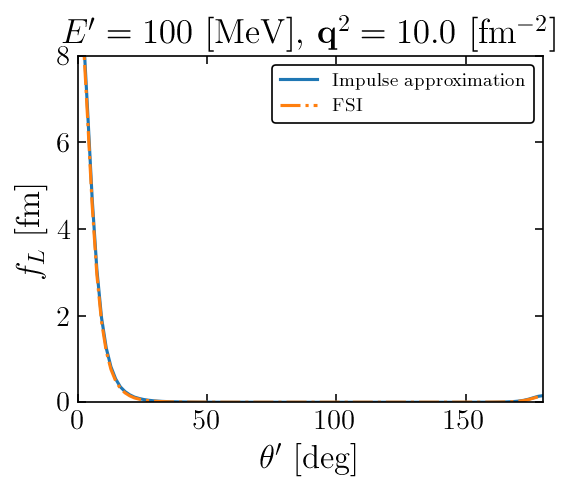

In [21]:
ylim = (0, 8)
Ep = 100
q = jnp.sqrt(10)
plot_fL_wrt_thetap(Ep, thetap_array, q, x_limits=xlim, y_limits=ylim)

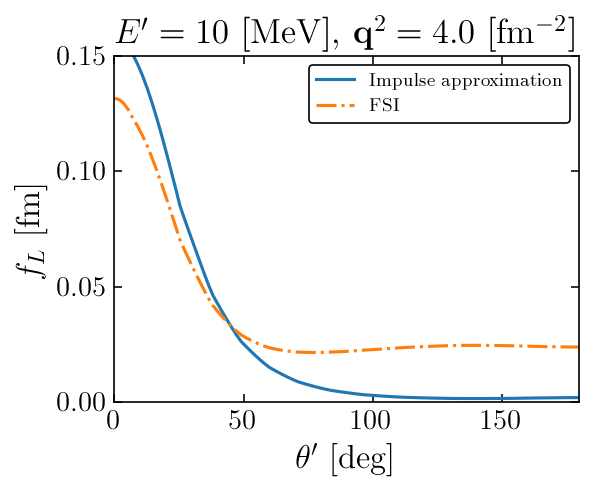

In [22]:
ylim = (0, 0.15)
Ep = 10
q = 2
plot_fL_wrt_thetap(Ep, thetap_array, q, x_limits=xlim, y_limits=ylim)

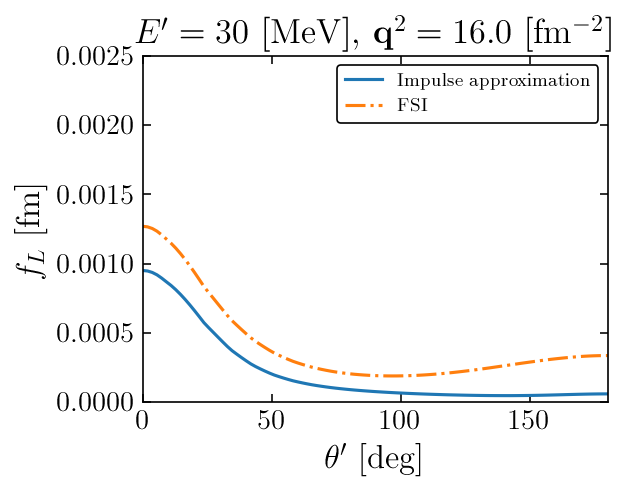

In [23]:
ylim = (0, 0.0025)
Ep = 30
q = 4
plot_fL_wrt_thetap(Ep, thetap_array, q, x_limits=xlim, y_limits=ylim)

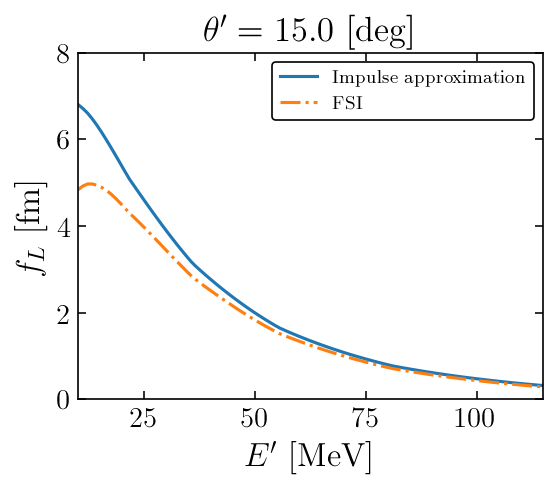

In [24]:
# Quasifree ridge where \omega = 0
Ep_array = np.linspace(10, 115, 100)
thetap = 15.0
xlim = (10, 115)
ylim = (0, 8)
plot_fL_quasifree_ridge(Ep_array, thetap, x_limits=xlim, y_limits=ylim, calc=True)
# plot_fL_quasifree_ridge(Ep_array, thetap, x_limits=xlim, y_limits=ylim, calc=False)